## Response to reviewers

This notebook addresses key reviewer comments from our manuscript revision. Specifically, we respond to the following points:

1. Concerns about the Fréchet Distance (FD) curves.

2. Limited overlap between real and synthetic data in the UMAP projections.

3. The need for a baseline to validate our classifier, particularly, whether training directly on EEG data improves performance and better tests if the critic has learned meaningful features.

Each section below provides updated analyses and visualizations to clarify or strengthen these aspects.

## Setup

In [ ]:
%reload_ext autoreload
%autoreload 2
import numpy as np
import torch
import seaborn as sns
from umap import UMAP
import hdbscan
import warnings
warnings.filterwarnings('ignore')
from matplotlib import pyplot as plt

import pandas as pd

from pathlib import Path

import os
os.environ['KERAS_BACKEND'] = 'torch'
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
from scipy.signal import welch
import xarray as xr
from scipy.signal import butter, sosfiltfilt

import torch
import keras

from scipy.stats import entropy, skew, kurtosis
from src.EEGModalNet.preprocessing.preprocessing import preprocess_data
from scipy.signal import resample

# Feature extraction
def time_domain_features_multi_channel(x, axis=-1):  # x: (n_samples, n_channels, n_timepoints)
    # mean = np.mean(x, axis=axis)
    # std = np.std(x, axis=axis)
    skewness = skew(x, axis=axis)
    kurtosis_ = kurtosis(x, axis=axis)
    # rms = np.sqrt(np.mean(x**2, axis=axis))
    return np.stack([skewness, kurtosis_], axis=-1)  # (n_samples, n_channels, n_features)

def hjorth_parameters_multi_channel(signal, axis=-1): 
    activity = np.var(signal, axis=axis)
    first_derivative = np.diff(signal, axis=axis)
    mobility = np.sqrt(np.var(first_derivative, axis=axis) / activity)
    second_derivative = np.diff(first_derivative, axis=axis)
    complexity = np.sqrt(np.var(second_derivative, axis=axis) / np.var(first_derivative, axis=axis)) / mobility
    return np.stack([activity, mobility, complexity], axis=-1)

def spectral_features_multi_channel(signal, fs=98, nperseg=512):
    f, Pxx = welch(signal, fs=fs, nperseg=nperseg, axis=-1)
    total_power = np.sum(Pxx, axis=-1)
    delta = np.sum(Pxx[:, :, (f >= 0.25) & (f < 4)], axis=-1) / total_power
    theta = np.sum(Pxx[:, :, (f >= 4) & (f < 8)], axis=-1) / total_power
    alpha = np.sum(Pxx[:, :, (f >= 8) & (f < 13)], axis=-1) / total_power
    beta = np.sum(Pxx[:, :, (f >= 13) & (f <= 30)], axis=-1) / total_power
    gamma = np.sum(Pxx[:, :, (f > 30) & (f <= 50)], axis=-1) / total_power
    pxx_entropy = entropy(Pxx, axis=-1)
    return np.stack([delta, theta, alpha, beta, gamma, pxx_entropy], axis=-1)

def aggregate_features(real_signal, gen_signal):
    # Extract features
    real_time_features = time_domain_features_multi_channel(real_signal)
    real_hjorth_features = hjorth_parameters_multi_channel(real_signal)
    real_spectral_features = spectral_features_multi_channel(real_signal)
    
    gen_time_features = time_domain_features_multi_channel(gen_signal)
    gen_hjorth_features = hjorth_parameters_multi_channel(gen_signal)
    gen_spectral_features = spectral_features_multi_channel(gen_signal)
    
    # Concatenate features
    real_features = np.concatenate([real_time_features, real_hjorth_features, real_spectral_features], axis=-1)
    gen_features = np.concatenate([gen_time_features, gen_hjorth_features, gen_spectral_features], axis=-1)
    
    return real_features, gen_features

def generate_data(model, x, sub, pos, latent_dim=128):
    B, T, C = x.shape
    x_mean = x.mean()
    x_std = x.std()
    l = len(x)
    x_gen = torch.zeros((B, T, C))
    for i in range(int(l/100)):
        x_gen[i*100:(i+1)*100] = model.generator((keras.random.normal((l, latent_dim), mean=x_mean, stddev=x_std),
                                                  sub[:l].to('mps'),
                                                  pos[:l].to('mps'))).cpu().detach()
    return x_gen

In [ ]:
# REAL DATA
# Data Parameters
FILTERING = True
TIME_DIM = 512
N_SUBJECTS = 150
EEG_DATA_PATH = 'data/X.nc5'
CHANNELS = ['O1', 'O2', 'P1', 'P2', 'C1', 'C2', 'F1', 'F2']
FS = 98

# Model parameters
LATENT_DIM = 128

# PATHS
STAT_PATH = 'logs/X.csv'
CHECKPOINTS_PATH = 'logs/X.keras'

xarray = xr.open_dataarray(EEG_DATA_PATH, engine='h5netcdf')

sub_id = np.random.randint(0, 202, N_SUBJECTS)
x = xarray.sel(subject=xarray.subject[sub_id], channel=CHANNELS)
x = x.to_numpy()

if FILTERING:
    sos = butter(4, 0.5, btype='high', fs=FS, output='sos')
    x = sosfiltfilt(sos, x, axis=-1)

x = torch.tensor(x.copy()).unfold(2, TIME_DIM, TIME_DIM).permute(0, 2, 3, 1).flatten(0, 1)
sub = torch.tensor(np.arange(0, N_SUBJECTS).repeat(x.shape[0]//N_SUBJECTS)[:, np.newaxis])
pos = torch.tensor(xarray.ch_positions[None].repeat(x.shape[0], 0))
data = {'x': x, 'sub': sub, 'pos': pos}

GENERATE_DATA = False
# FAKE DATA
from src.EEGModalNet.models.WGAN import WGAN_GP
model = WGAN_GP(time_dim=512, feature_dim=len(CHANNELS),
                latent_dim=LATENT_DIM, n_subjects=202,
                use_sublayer_generator=True,
                use_sublayer_critic=True,
                use_channel_merger_g=False,
                use_channel_merger_c=False,
                interpolation='bilinear')

if GENERATE_DATA:
    with torch.no_grad():
        x_fake = generate_data(model, x, sub, pos, latent_dim=LATENT_DIM)

else:  # in this case the previously generated data will be opened
    data = np.load('data/LEMON_DATA/real_fake.npz')
    x_real = torch.from_numpy(data['real']).flatten(1, 2)
    x_fake = torch.from_numpy(data['fake']).flatten(1, 2)
    x = torch.cat([x_real, x_fake], dim=0).float()

## UMAP

In this section, we applied clustering to the 2D UMAP components using the HDBSCAN algorithm. The results indicate that the regions where the real and fake data do not overlap are primarily labeled as noise by HDBSCAN (i.e., assigned a label of -1). In contrast, the dense core region—representing high-density areas—shows substantial overlap between real and fake samples, although not entirely complete.

In the figure below, the left subplot displays the HDBSCAN clustering labels of the 2D UMAP representation of the real data. The right subplot shows both real and fake samples in the same 2D space, color-coded accordingly, with the noise-labeled points from the real data highlighted

Text(0.5, 0, 'UMAP 1')

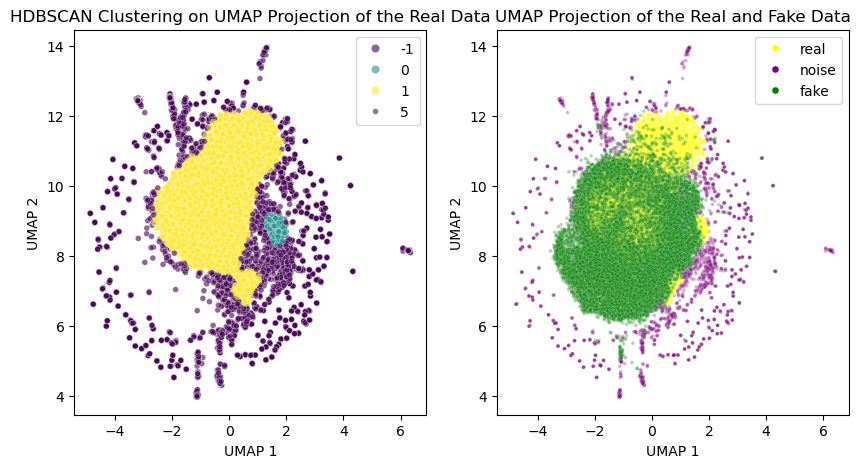

In [ ]:
# UMAP
umapper = UMAP()
x_umap = umapper.fit_transform(x)

l = len(x_real)
clusterer = hdbscan.HDBSCAN(min_cluster_size=200)
labels = clusterer.fit_predict(x_umap[:l])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# Visualization of Clusters
g = sns.scatterplot(
    x= x_umap[:l, 0],
    y= x_umap[:l, 1],
    hue=labels,
    palette='viridis',
    alpha=0.6,
    size=5,
    ax=axes[0]
)

g.set_title('HDBSCAN Clustering on UMAP Projection of the Real Data')
g.set_ylabel('UMAP 2')
g.set_xlabel('UMAP 1')

noise_idx = np.where(labels == -1)[0].tolist()
mask = ['real'] * len(x_real) + ['fake'] * len(x_fake)
for i in noise_idx:
    mask[i] = 'noise'

g = sns.scatterplot(
    x=x_umap[:, 0],
    y=x_umap[:, 1],
    hue=mask[:],
    palette=['yellow', 'purple', 'green'],
    alpha=0.3,
    s=7,
    ax=axes[1]
)

handles, labels = g.get_legend_handles_labels()
for artist in handles:
    artist.set_alpha(1.0)
    artist.set_markersize(5)
g.legend(handles, labels, loc='upper right')
g.set_title('UMAP Projection of the Real and Fake Data')
g.set_ylabel('UMAP 2')
g.set_xlabel('UMAP 1')

## Fréchet Distance
We agree with the reviewer that this figure could be improved. Our original goal was to show how the similarity between real and fake data evolves during training, using Fréchet Distance (FD) on manually extracted features. We expected the FD to decrease over time, but that trend isn’t clearly visible here.

This might be due to the adversarial nature of GANs, where progress isn't always smooth, or because we used handcrafted features, which may not fully capture the complex patterns the model learns. Also, FD might not be the best choice in this context, applied to low-level statistical features such as skewness, kurtosis, and frequency band power. These features may not capture the higher-order dependencies and nuances that the GAN is learning to mimic.

To give a clearer picture, we now show the distribution of these features at an early training epoch (60) and at the final one (900), to better illustrate how the generated data changes. Still, we agree that this approach has its limits, and a future version of the paper could benefit from more informative metrics or learned features.

In [ ]:
f_names = ['skewness', 'kurtosis', 'activity', 'mobility', 'complexity',
           'delta', 'theta', 'alpha', 'beta', 'gamma', 'entropy']

epoch = 60
path = Path(f'logs/20250321_epoch_{epoch}.model.keras')
model.load_weights(path)
# generated data
bs = 128
with torch.no_grad():
    x_gen = generate_data(model, x, sub, pos, latent_dim=LATENT_DIM)

tr_sh = (x_gen.shape[0]//bs)*bs
x_gen = x_gen[:tr_sh]
real_f, fake_f = aggregate_features(x[:tr_sh].permute(0, 2, 1).cpu().detach().numpy(), x_gen.permute(0, 2, 1).cpu().detach().numpy())  # TODO: remove l from x

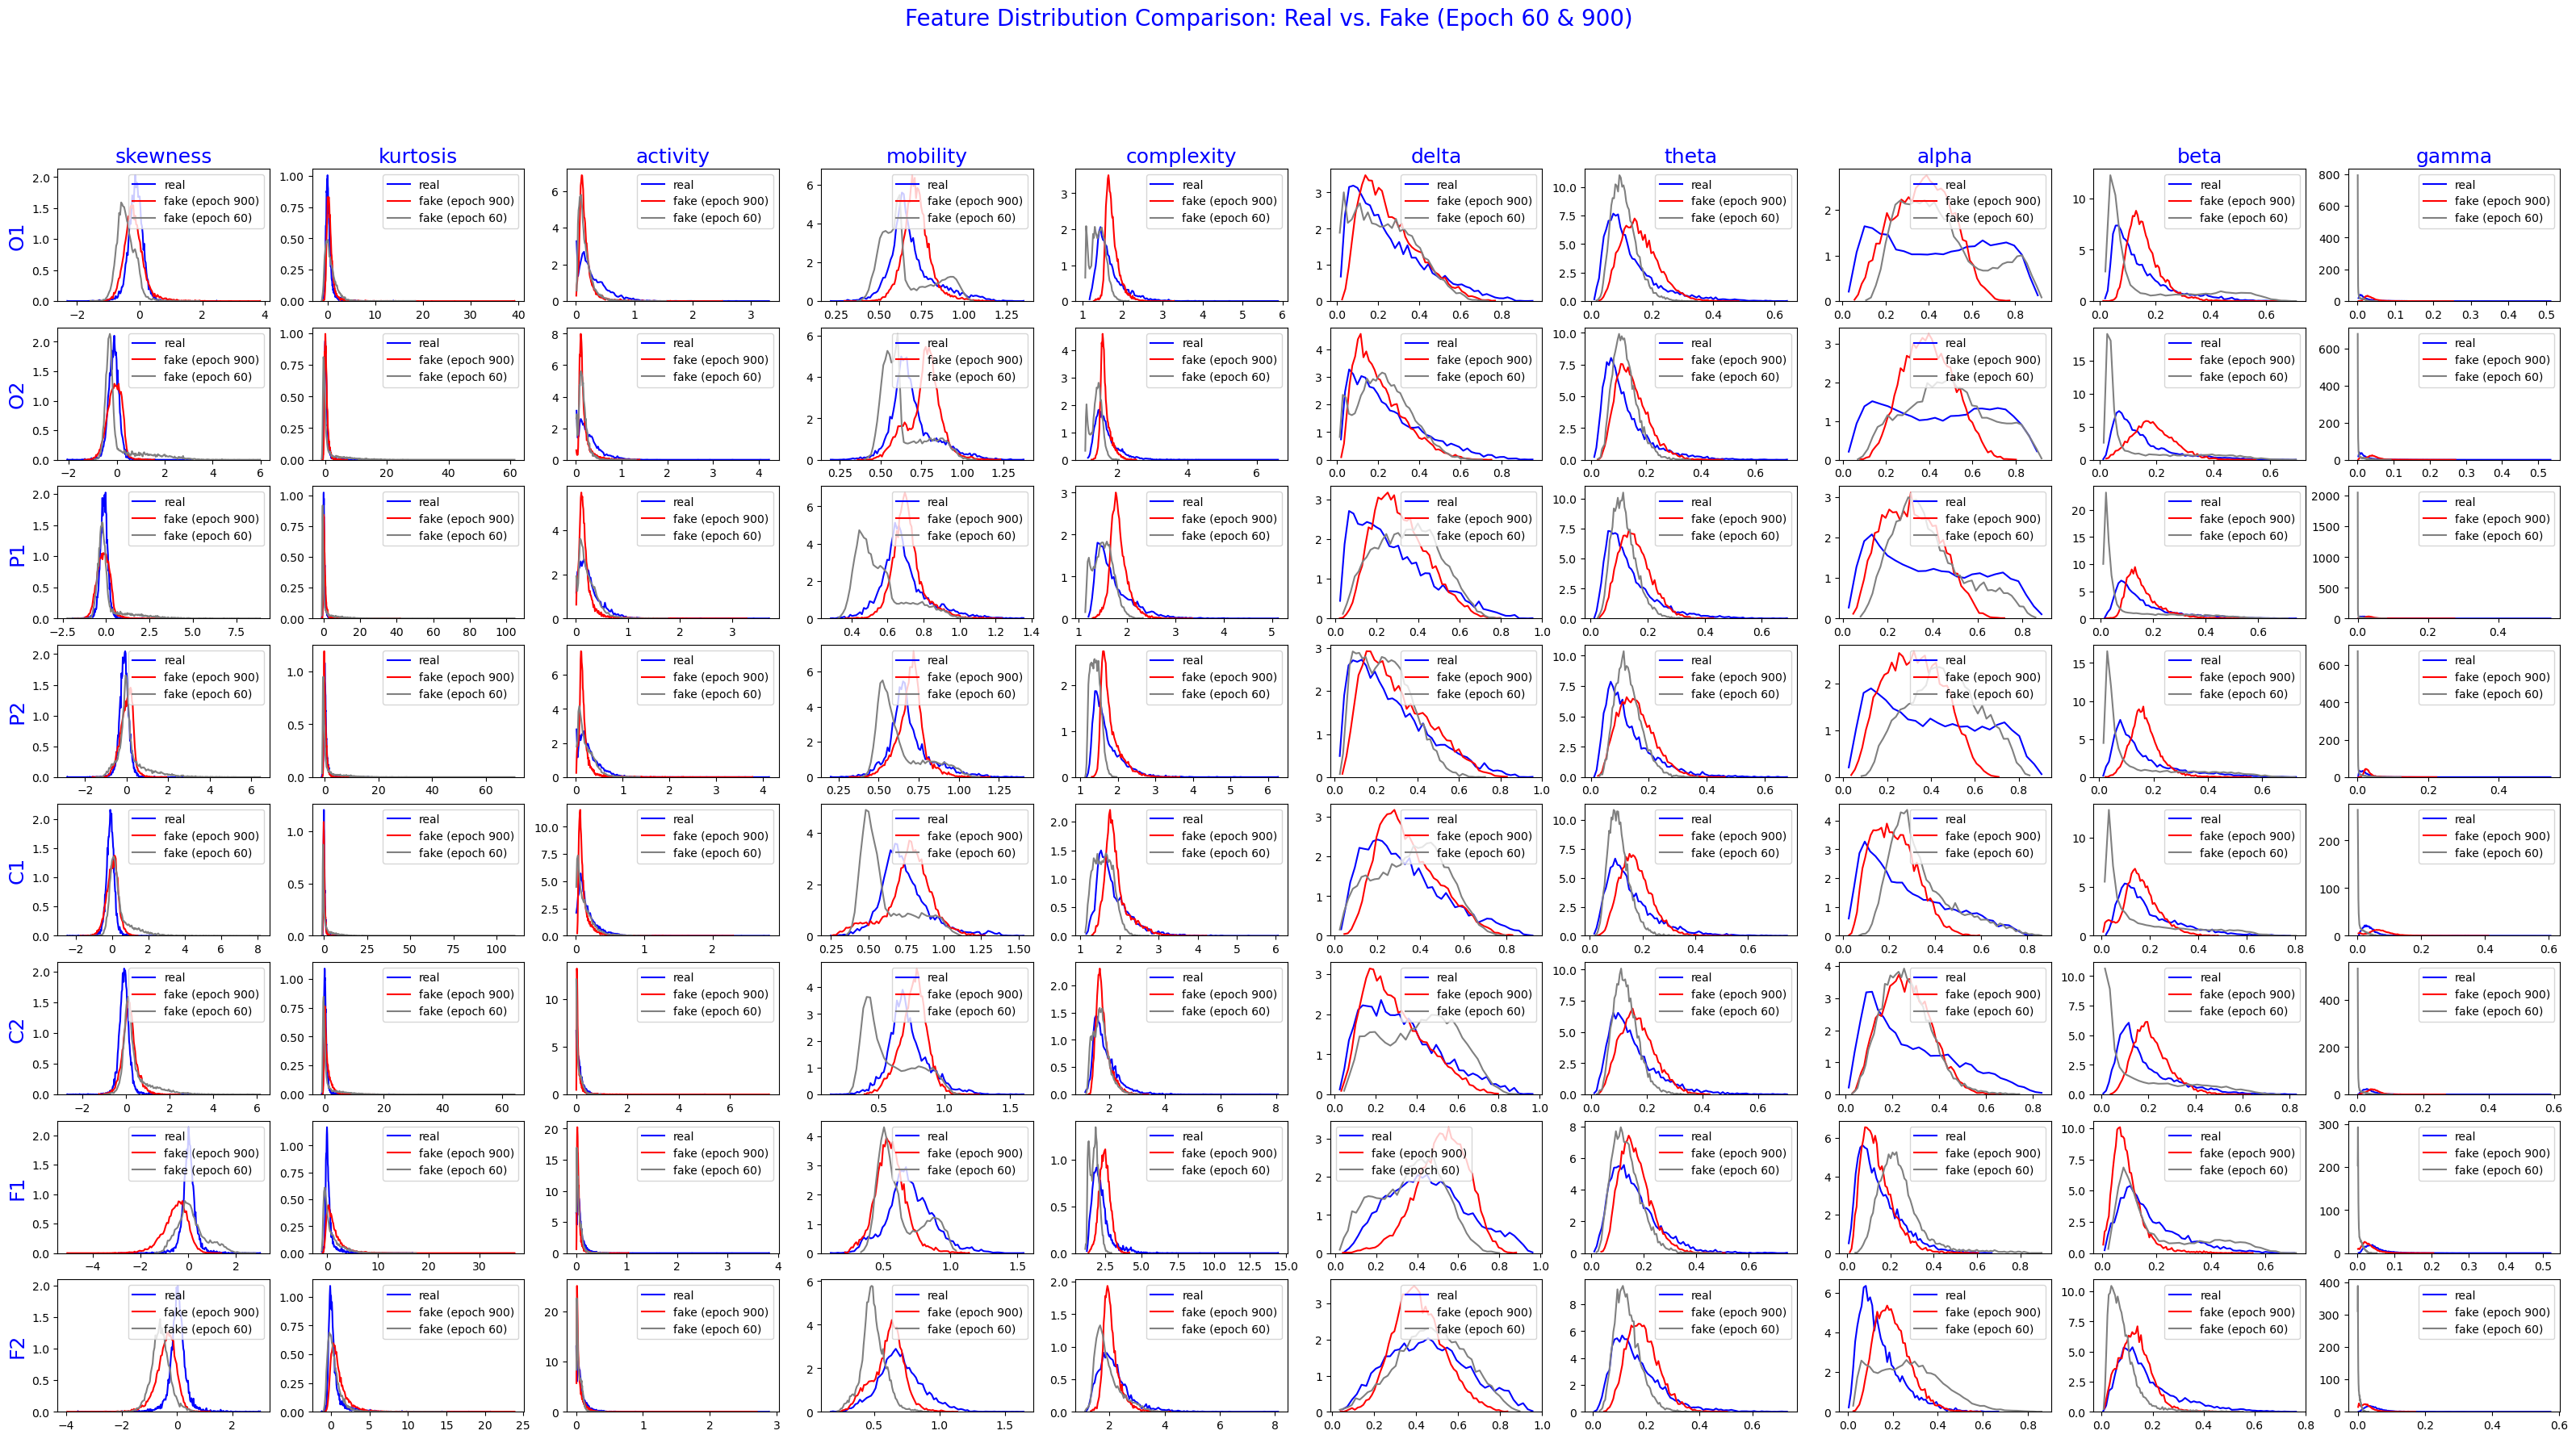

In [33]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(8, 10, figsize=(40, 20))
brain_areas = ['occipital', 'parietal', 'central', 'frontal']
for ch_idx in range(len(CHANNELS)):
    for fn in range(len(f_names[:-1])):
        sns.histplot(real_f_final[:, ch_idx, fn], color='blue', kde=False, element='poly', fill=False, ax=axes[ch_idx, fn], label='real', stat='density')
        sns.histplot(fake_f_final[:, ch_idx, fn], color='red', kde=False, element='poly', fill=False, ax=axes[ch_idx, fn], label='fake (epoch 900)', stat='density')
        sns.histplot(fake_f[:, ch_idx, fn], color='gray', kde=False, element='poly', fill=False, ax=axes[ch_idx, fn], label='fake (epoch 60)', stat='density')
        axes[ch_idx, fn].legend()
        if ch_idx == 0:
            axes[ch_idx, fn].set_title(f_names[fn], fontsize=18, color='blue')
        if fn == 0:
            axes[ch_idx, fn].set_ylabel(CHANNELS[ch_idx], fontsize=18, color='blue')
        else:
            axes[ch_idx, fn].set_ylabel('')
fig.suptitle('Feature Distribution Comparison: Real vs. Fake (Epoch 60 & 900)', color='blue', fontsize=20)
plt.show()

## Classification

In response to your comment, we used the minimally processed EEG data (as described in the manuscript) to predict participants’ age, using the same held-out dataset referenced earlier. For this, we flattened each EEG segment across the time (512) and channel (8) dimensions into a single 4096-length vector—yielding an input shape of (batch size, 4096).

Using the same classifier architecture detailed in the paper, the validation accuracy plateaued at 56%, even after 1000 training epochs. We experimented with increasing the number of neurons (from 64 to 256), adding dropout layers, scaling the data, and applying PCA to reduce dimensionality, but none of these improved performance.

The figure below shows accuracy, validation accuracy, loss, and validation loss across the various approaches we tried for this classification task using raw EEG as input.

In [ ]:
# eeg data is experience data that is downsampled to 128Hz and Robustly scaled
EEG = xr.open_dataarray('data/X.nc5', engine='h5netcdf')
behavioral = pd.read_csv('data/X.csv')

classes = behavioral[['gender', 'bids_id']].dropna().set_index('bids_id')
classes['gender'] = classes['gender'].apply(lambda x: 0 if x == 'Male' else 1)

time_dim = 512

def format_subject_id(subject_id):
    return f"sub-{int(subject_id):02d}"
n_y0 = (classes == 0).sum().values
n_y1 = (classes == 1).sum().values
n_min = min(n_y0, n_y1)
n_subjects = n_min * 2
y0_sub_ids = classes.query("gender == 0").index[:n_min[0]]
y1_sub_ids = classes.query("gender == 1").index[:n_min[0]]
sub_ids = y0_sub_ids.append(y1_sub_ids)

sub_ids_formatted = [format_subject_id(sub_id) for sub_id in sub_ids]

# X_input
x = EEG.sel(subject=sub_ids_formatted, channel=CHANNELS).to_numpy()
n_samples = int((x.shape[-1] / 128) * 98)
x = resample(x, num=n_samples, axis=-1)
x = x.reshape(-1, *x.shape[2:])
x = preprocess_data(x, sampling_rate=98)

# lowpass filter
sos = butter(4, 0.5, btype='high', fs=98, output='sos')
x = sosfiltfilt(sos, x, axis=-1)
x = torch.tensor(x.copy()).unfold(2, time_dim, time_dim).permute(0, 2, 3, 1).flatten(0, 1)

# Classes
n_subjects = len(sub_ids)
y = classes.loc[sub_ids].values
y = y.repeat(x.shape[0] / n_subjects)
# from random import shuffle
# shuffle(y)

# Groups
sub = torch.tensor(np.arange(0, n_subjects).repeat(x.shape[0] // n_subjects)[:, np.newaxis])
groups = sub.squeeze().numpy()


USE_RAW_EEG = True
if USE_RAW_EEG:
    X_e = x.flatten(1, 2)

# SPLIT
from sklearn.model_selection import ShuffleSplit, GroupShuffleSplit
DO_GROUPED_SHUFFLE = False

if DO_GROUPED_SHUFFLE:
    group_shuffle = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=5)
    train_idx, val_idx = next(group_shuffle.split(X_e, y, groups=groups))
else:
    random_shuffle = ShuffleSplit(n_splits=1, test_size=0.3, random_state=1)
    train_idx, val_idx = next(random_shuffle.split(X_e, y))

print(y.mean(), y[train_idx].mean(), y[val_idx].mean())


cls_model = keras.models.Sequential([   
    keras.layers.Dense(256, activation='gelu'),
    keras.layers.Dense(1, activation='sigmoid')
])

cls_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy'])

history = cls_model.fit(
    X_e[train_idx], y[train_idx],
    epochs=1000,
    batch_size=256,
    validation_data=(X_e[val_idx], y[val_idx]),
    shuffle=True)

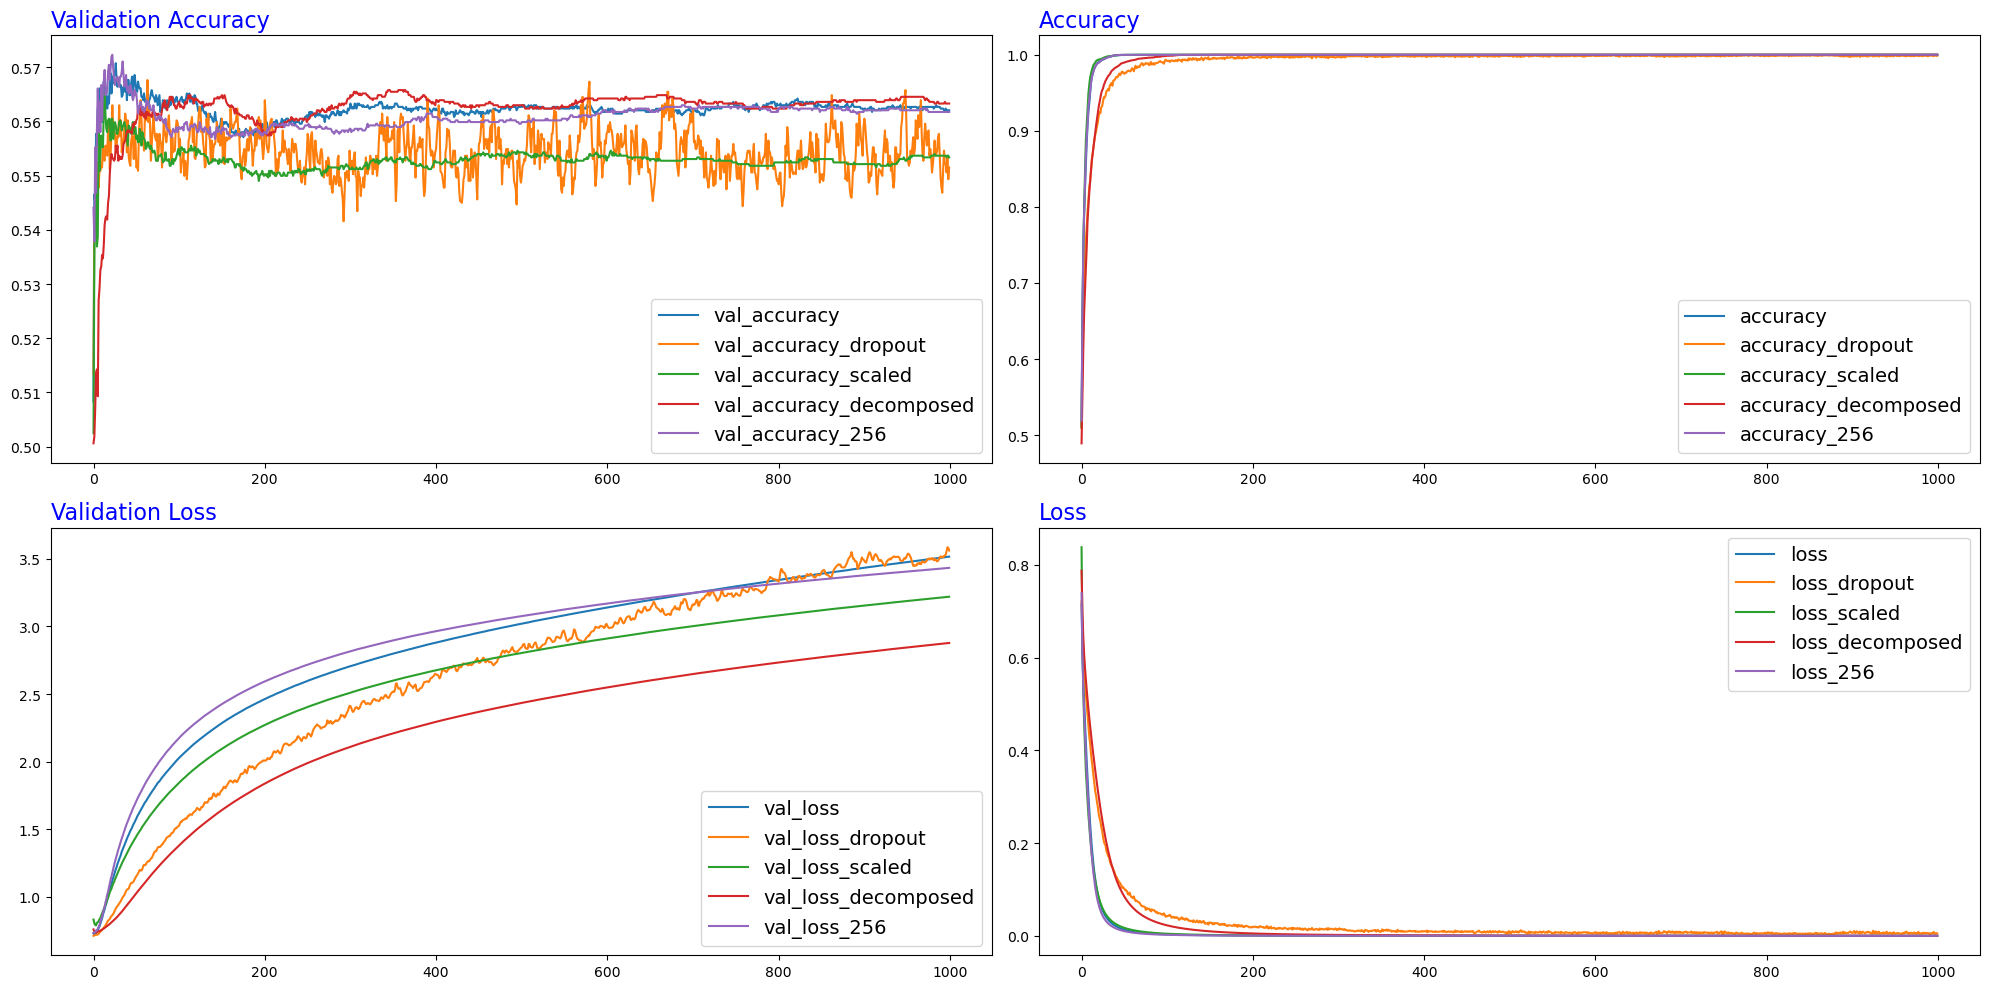

In [ ]:
history = pd.DataFrame(history.history)
fig, ax = plt.subplots(2, 2, figsize=(20, 10))

acc_cols = [i for i in history.columns if 'accuracy' in i and 'val' not in i]
loss_cols = [i for i in history.columns if 'loss' in i and 'val' not in i]
acc_val_cols = [i for i in history.columns if 'val_acc' in i]
acc_loss_cols = [i for i in history.columns if 'val_loss' in i]

for col in acc_val_cols:
    ax[0, 0].plot(history[col], label=col)
    ax[0, 0].set_title('Validation Accuracy', fontsize=16, color='blue', loc='left')
    ax[0, 0].legend(fontsize=14)

for col in acc_cols:
    ax[0, 1].plot(history[col], label=col)
    ax[0, 1].set_title('Accuracy', fontsize=16, color='blue', loc='left')
    ax[0, 1].legend(fontsize=14)

for col in acc_loss_cols:
    ax[1, 0].plot(history[col], label=col)
    ax[1, 0].set_title('Validation Loss', fontsize=16, color='blue', loc='left')
    ax[1, 0].legend(fontsize=14)

for col in loss_cols:
    ax[1, 1].plot(history[col], label=col)
    ax[1, 1].set_title('Loss', fontsize=16, color='blue', loc='left')
    ax[1, 1].legend(fontsize=14)

plt.tight_layout()